In [16]:
import sys
sys.path.append('../src')
from utils.stock_simulation import Stock
from utils.report import fast_config
from utils.simulation import save_session, load_session
from utils.simulation.session import save_markets, load_markets

Markets loaded ← c:\Users\cleme\OneDrive\Documents\Travail\Dauphine\M2\Electronic Market\project\fx_market_making\test\..\src\utils\simulation\saved_markets.pkl


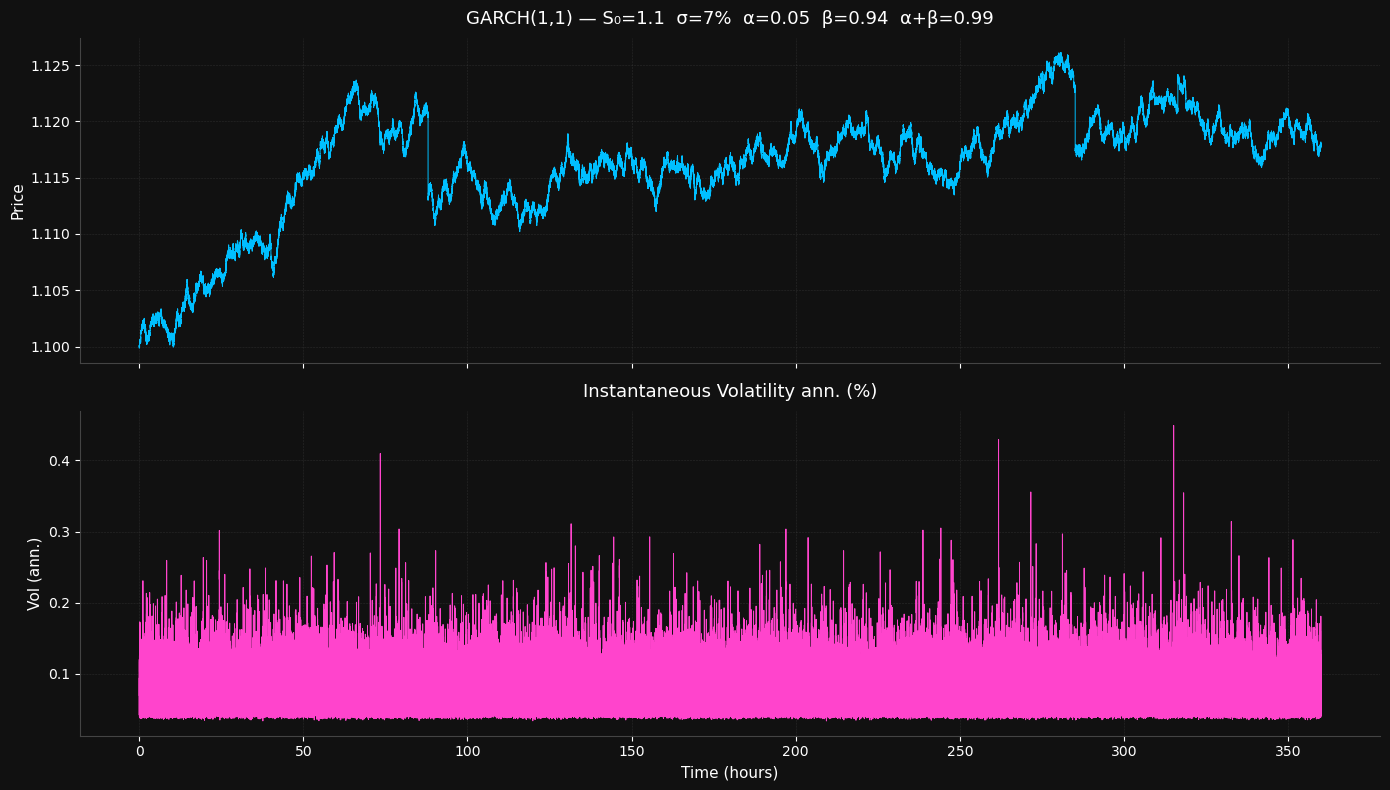

────────────────────────────────────────────────────────────────────────────
Metric                                               Skewed
────────────────────────────────────────────────────────────────────────────
Spread mean (price units)                            0.0002
Spread std  (price units)                            0.0000
Spread min  (price units)                            0.0002
Spread max  (price units)                            0.0002
Relative spread mean (%)                           0.0149%
Relative spread std  (%)                           0.0002%
Ask bias vs mid (mean)                               0.0001
Bid bias vs mid (mean)                               0.0001
Ask vol (ann., log-ret)                            8.0363%
Bid vol (ann., log-ret)                            8.0363%
Quote center offset (mean)                          -0.0000
Ask half − Bid half (mean)                          -0.0000
──────────────────────────────────────────────────────────────────────

In [17]:
# ── RUN ONCE to generate markets, then comment out ──────────────────────────
# Regenerate only when you want a new price path or spread shape.

# stock = Stock(drift=0.0, vol=0.07, origin=1.10)
# stock.simulate_garch(n_days=15, dt_seconds=0.05,
#                      alpha=0.05, beta=0.94,
#                      lam=100,       # 100 jumps/year ≈ 2/week  (was 300 = 1.2/day, too frequent)
#                      sigma_J=0.005) # ±0.5% per jump std ≈ 55 pips on EUR/USD
# market_B, market_C = fast_config.build_markets_B_C(stock)
# save_markets(stock, market_B, market_C)

# ── ALWAYS: load saved markets ───────────────────────────────────────────────
stock, market_B, market_C = load_markets()
stock.plot_vol_path()
#market_B.plot_noised_mid_price()
market_B.sanity_check_spreads()
#market_C.plot_noised_mid_price()
market_C.sanity_check_spreads()

In [18]:
# ── RUN EVERY TIME: rebuild MM + book + controller from current fast_config ──
# Changes to fast_config.py (gamma, delta_limit, ...) are picked up here.
market_maker, book = fast_config.build_market_maker_and_order_book(market_B, market_C)
controller = fast_config.build_controller(market_B, market_C, book, market_maker)

In [19]:
controller.simulate(limit = stock.n_steps)

  2%|▏         | 454959/25920000 [00:34<32:33, 13035.69it/s]


KeyboardInterrupt: 

════════════════════════════════════════════════════════════════════
  BACKTESTING REPORT — Phase 1   (15.0 days, dt=0.1s, 25,920,000 steps)
════════════════════════════════════════════════════════════════════
  Total MtM P&L                             +2652.80  USD
    Realized cash P&L                     -140712.98  USD
    Unrealized (open inventory × mid)      +143365.78  USD
────────────────────────────────────────────────────────────────────
  Inception spread P&L                      +6699.10  USD
    (spread captured at fill time)  
  Inventory revaluation P&L                 -1838.36  USD
    (mid drift on open EUR position)
  Total fees paid                            2207.93  USD
    Maker fees (exchange A)                  1987.75  USD
    Taker fees (hedge B/C)                    220.18  USD
────────────────────────────────────────────────────────────────────
  MM fills                                     6,441  (429/day)
  Hedge legs                                     

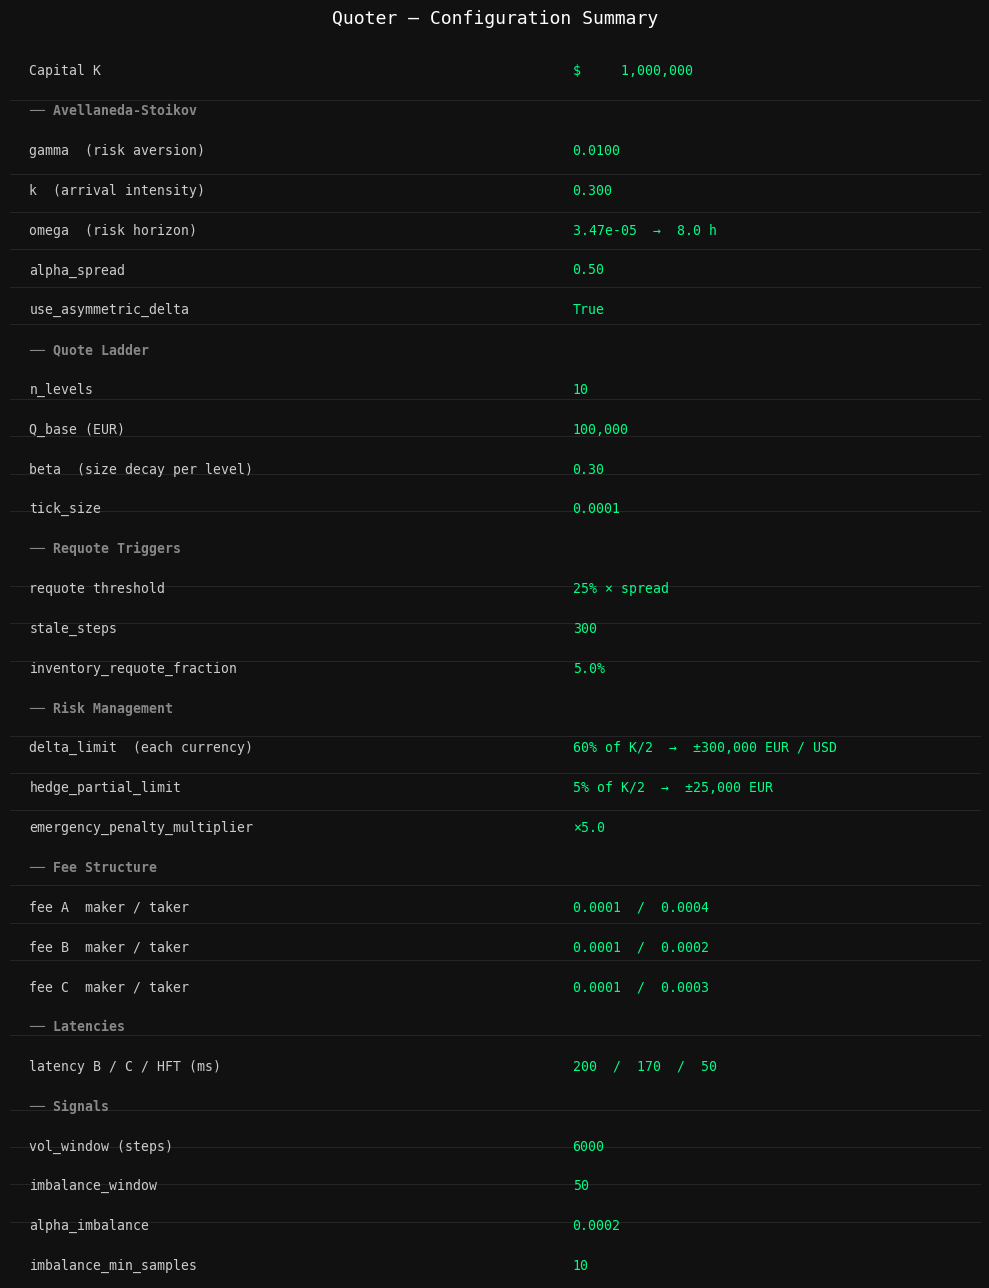

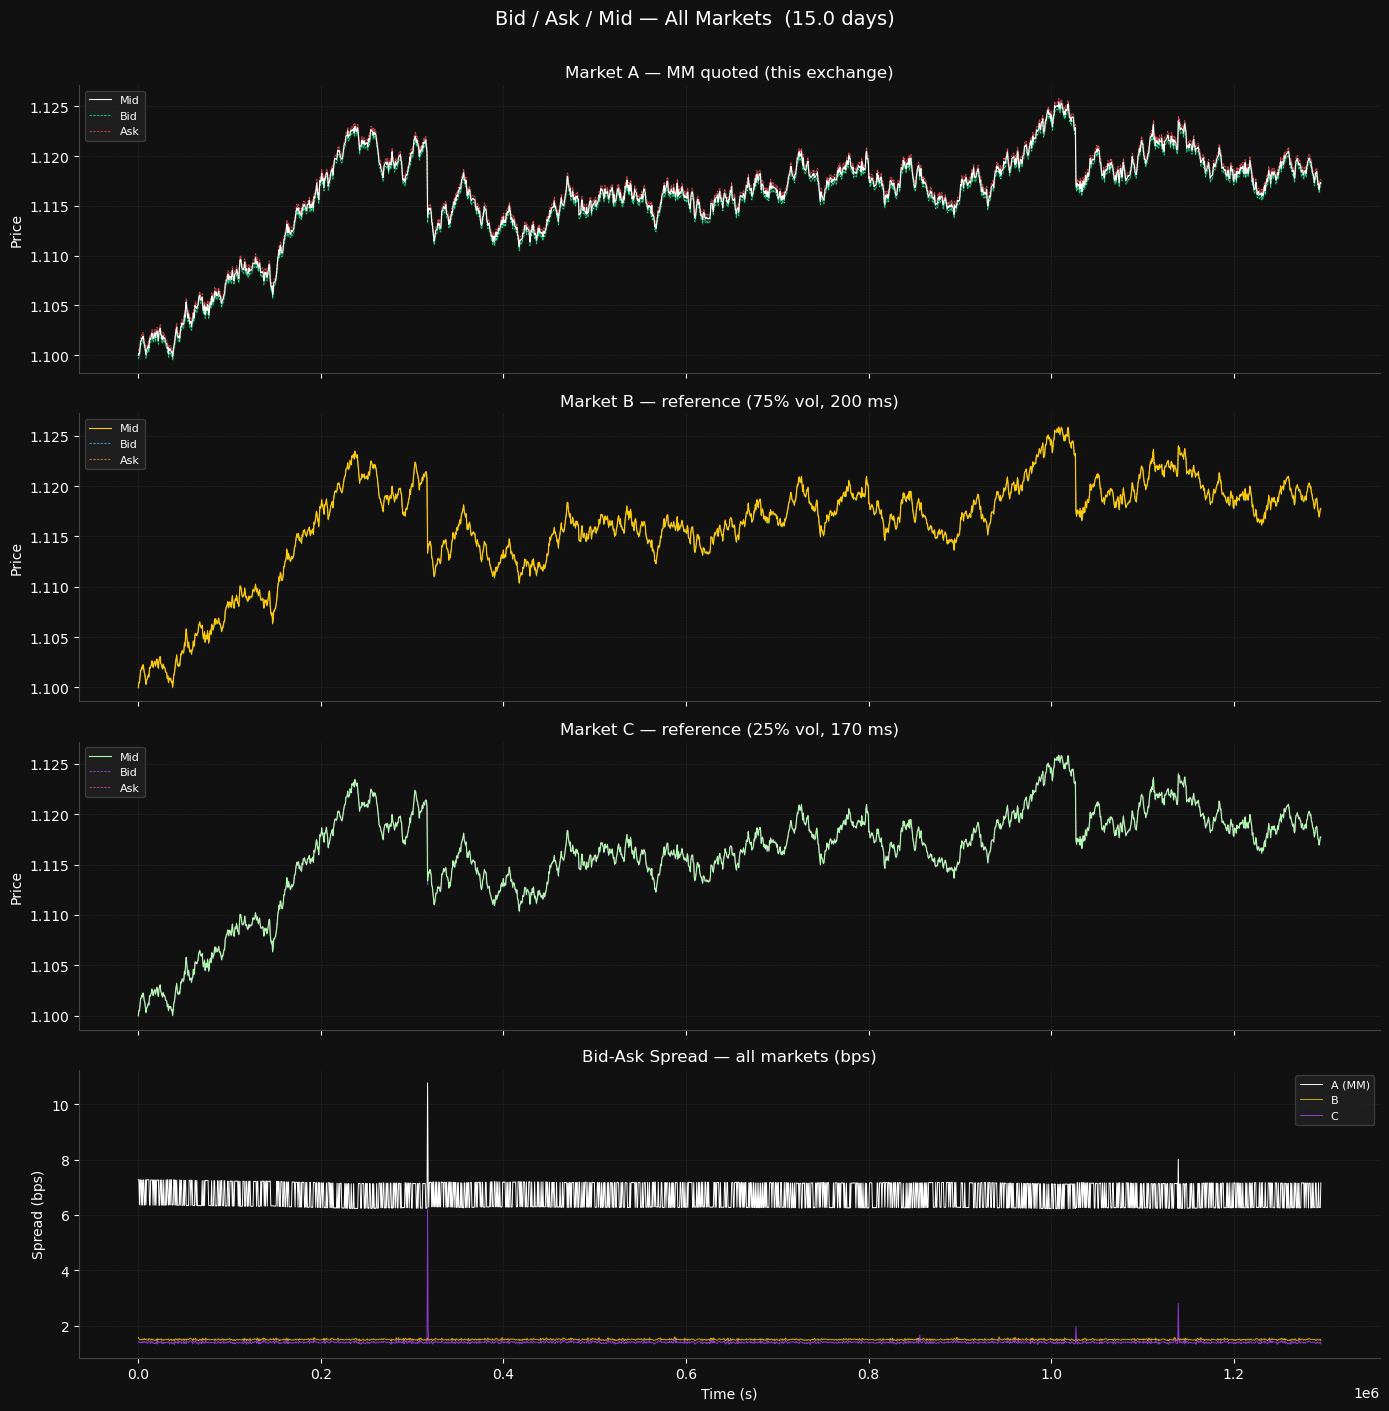

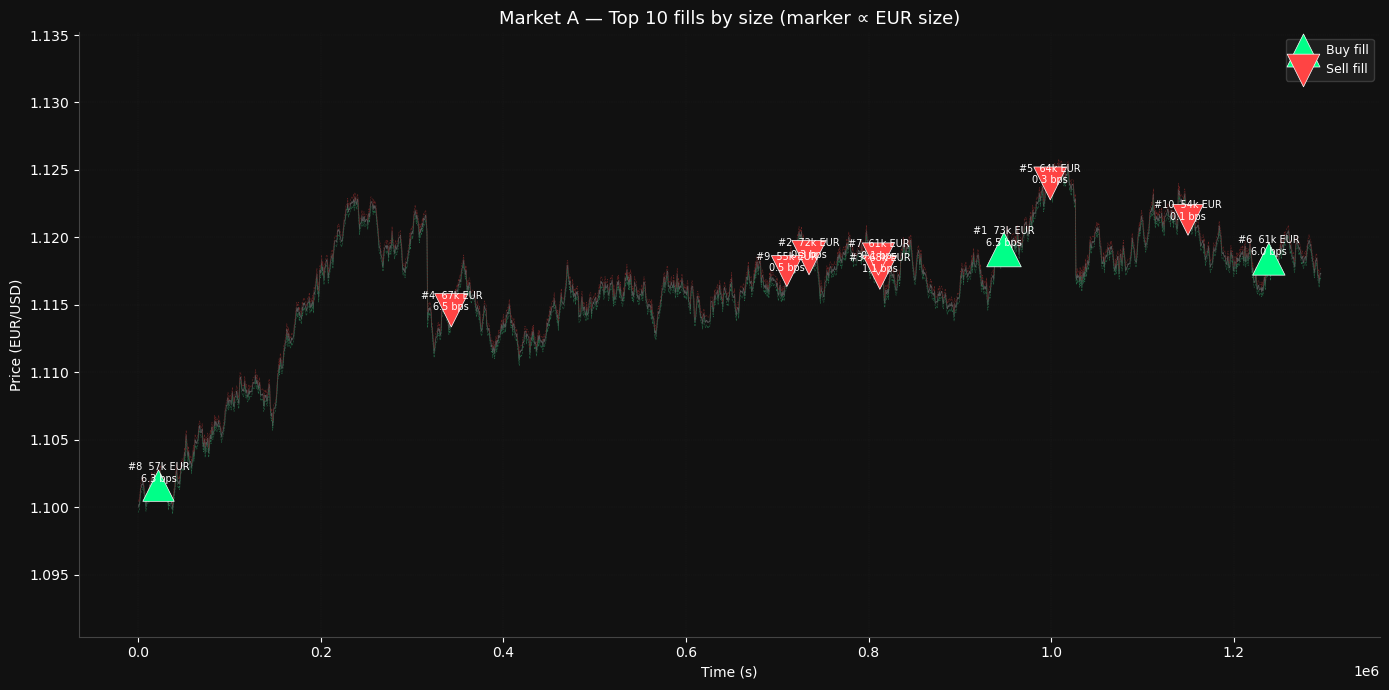

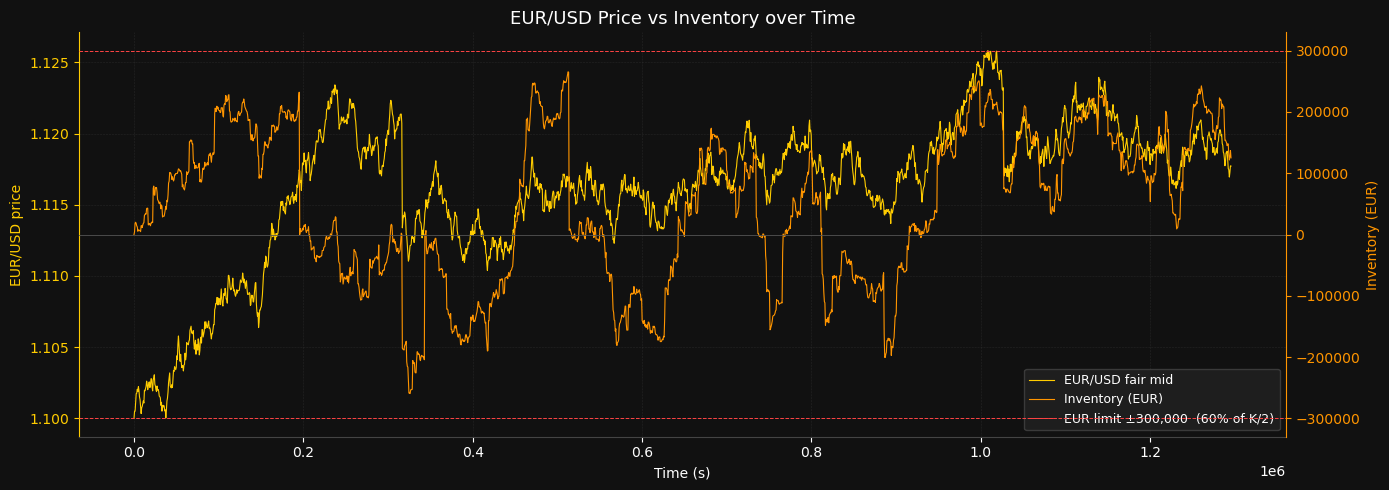

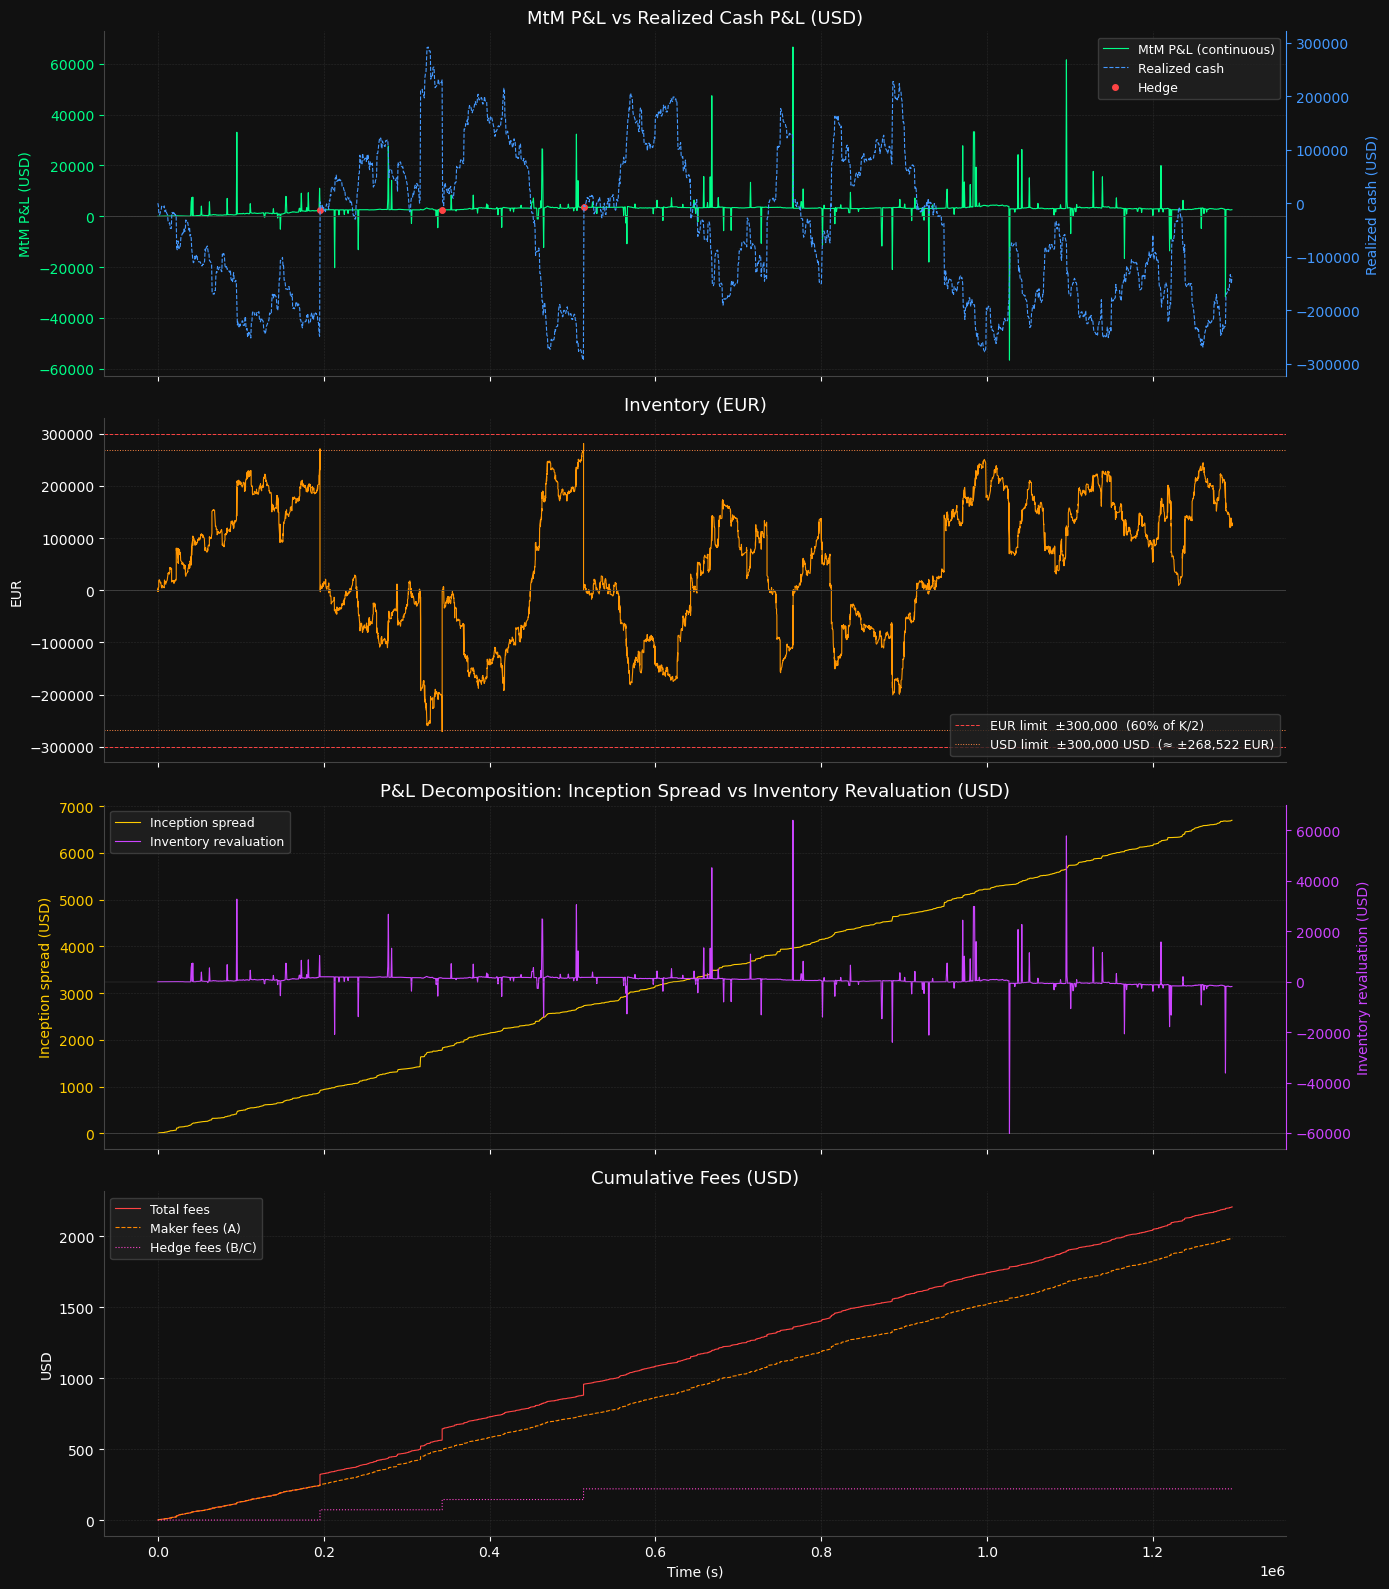

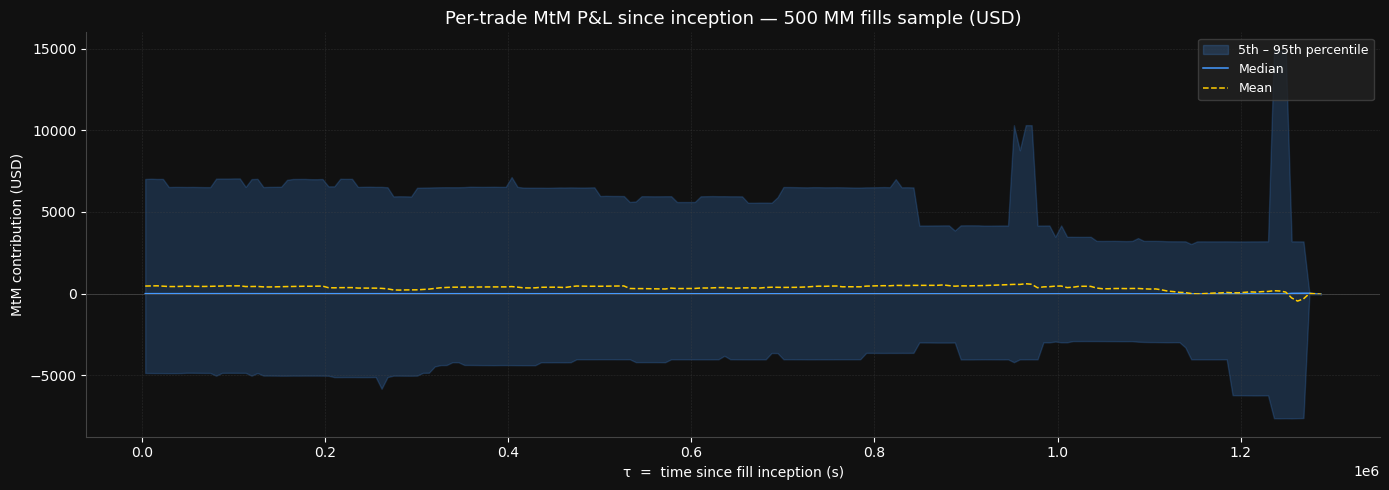

────────────────────────────────────────────────────────────────────
  FILL-RATE ANALYSIS
────────────────────────────────────────────────────────────────────
  MM fills                                     6,441
  Quotes posted                              451,970
  Overall fill rate                          1.4251%
  Avg fill size (EUR)                          2,765
  Full fills                                    0.1%
  Partial fills                                99.9%
────────────────────────────────────────────────────────────────────
  Level         Fill count   Relative rate
  1                  6,415           1.000
  2                     18           0.003
  3                      2           0.000
  4                      6           0.001
════════════════════════════════════════════════════════════════════


In [ ]:
controller.report()

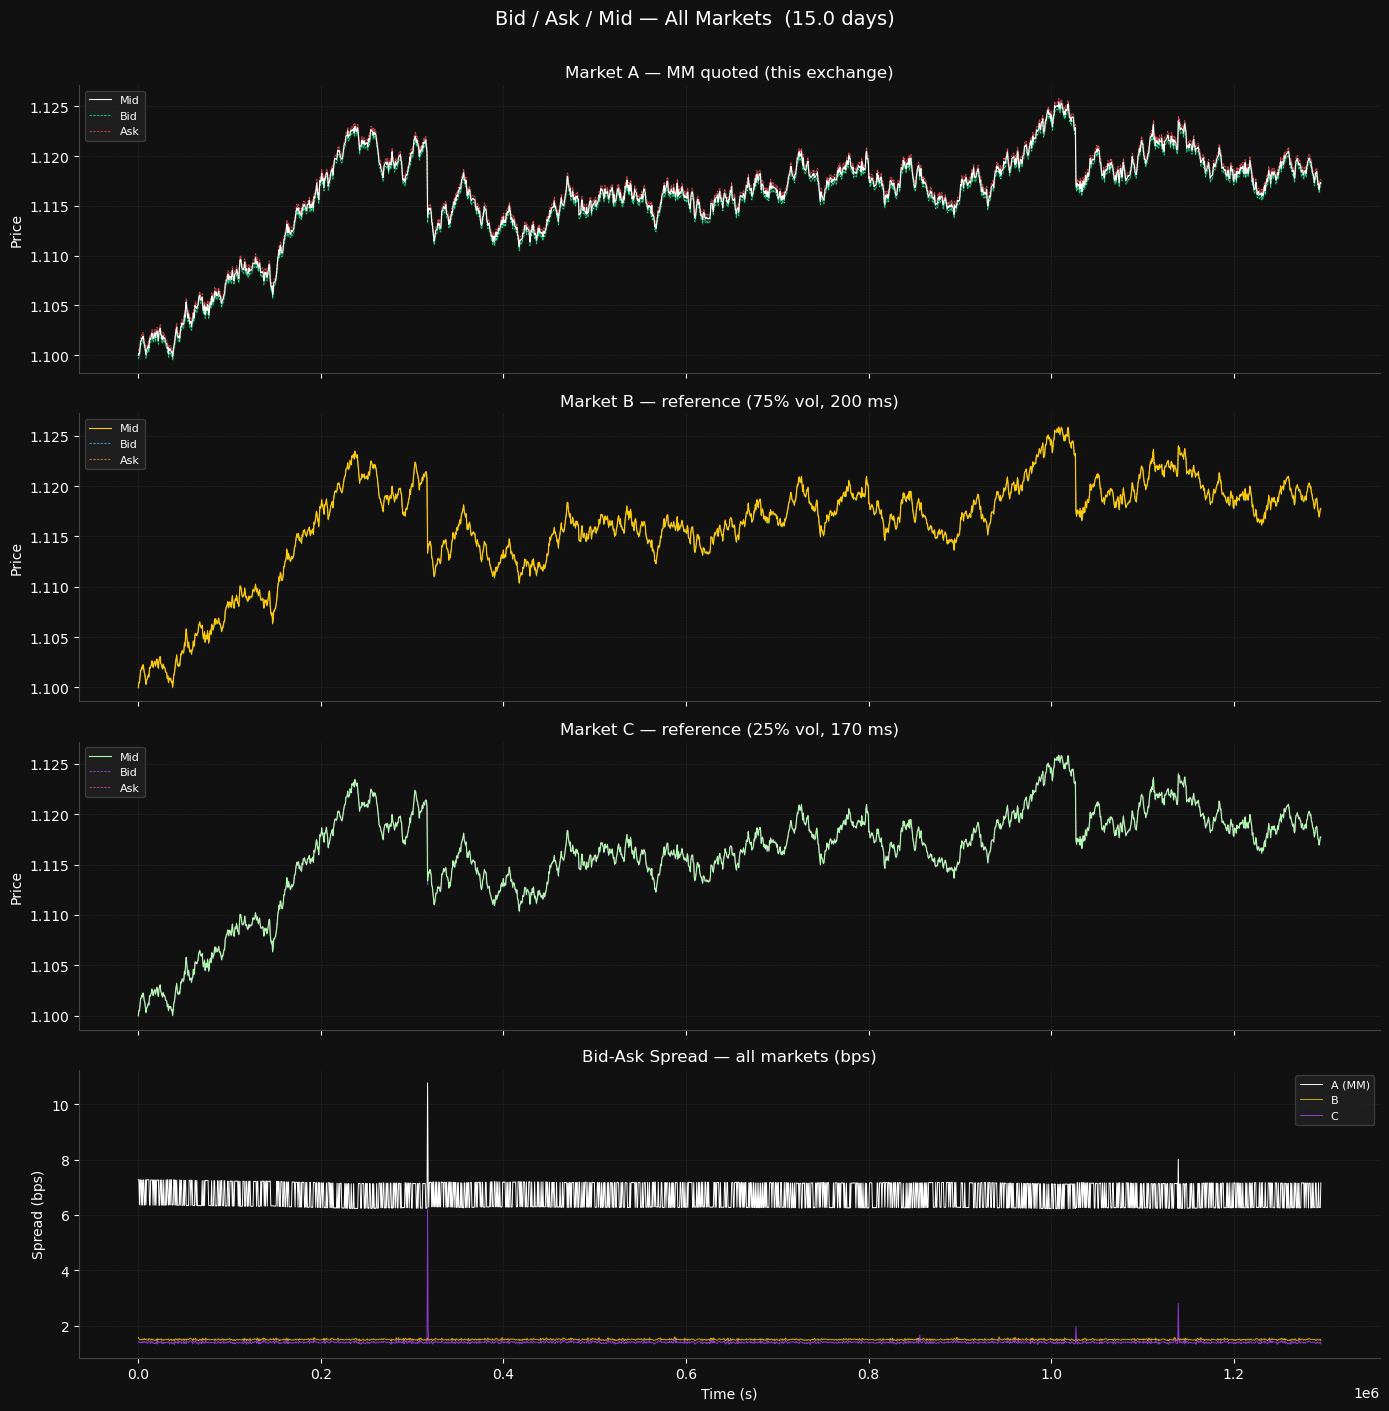

In [ ]:
controller.plot_market_quotes()

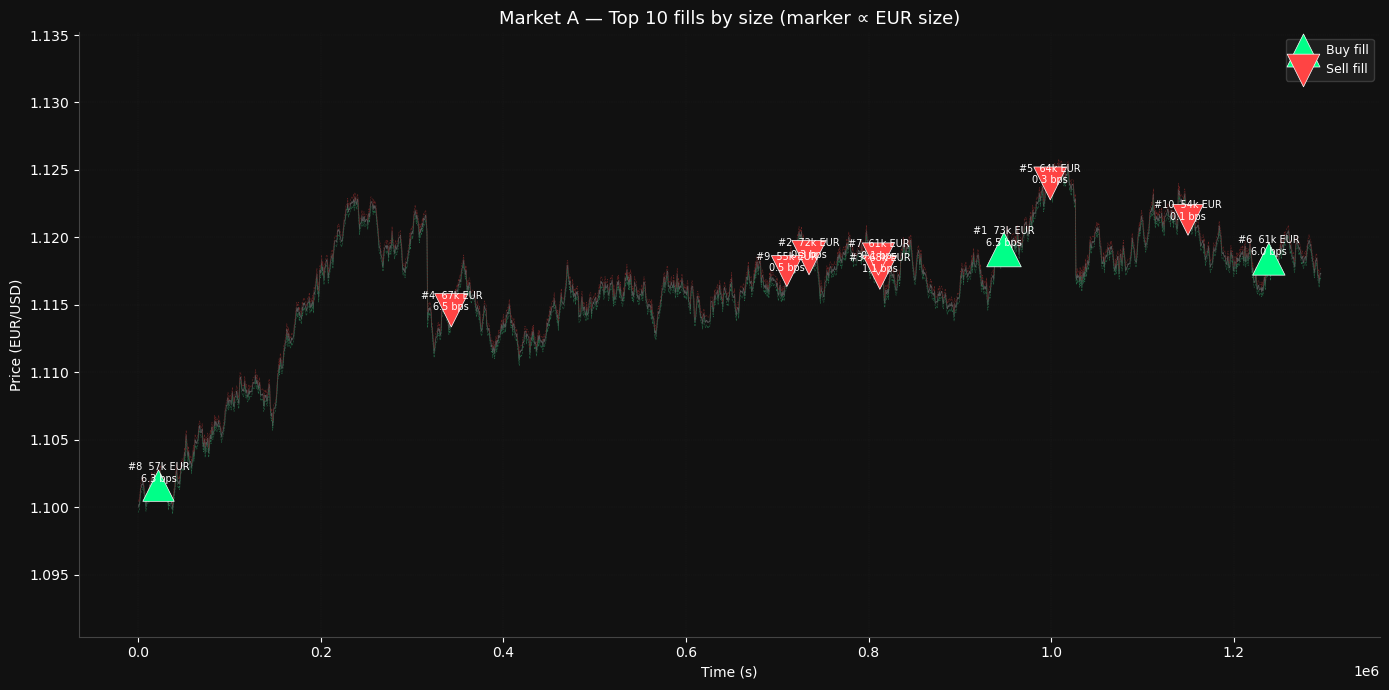

In [ ]:
controller.plot_top_trades()

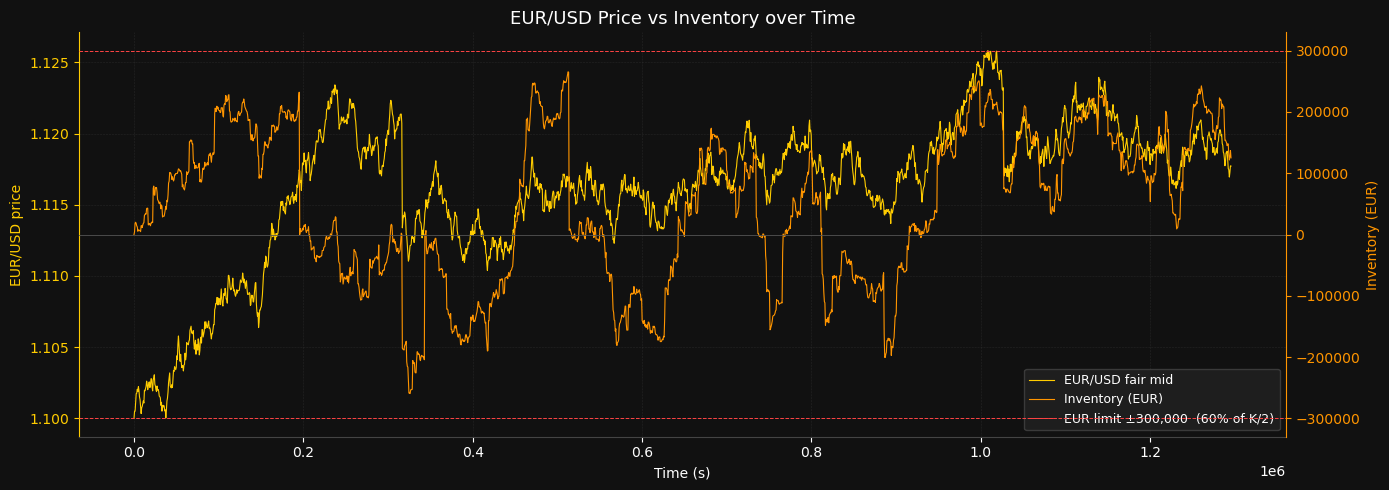

In [ ]:
controller.plot_price_inventory()

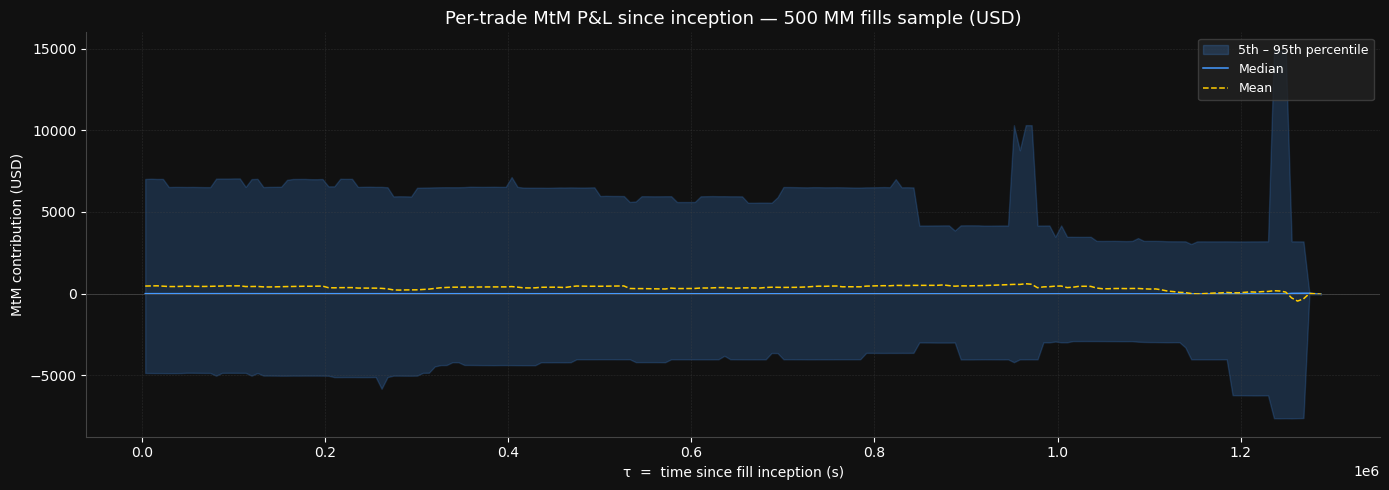

In [ ]:
controller.plot_mtm_percentiles()

## Result Analysis

Post-run diagnosis of the 15-day GARCH+jump Phase-1 simulation (config: `fast_config.get_standard_demo_config()` with `gamma=0.01`, `delta_limit=0.60`, `hedge_partial_limit=0.05`, capital $1M; client flow `A=0.007 s^-1`, `k=0.3 bp^-1`).

**Headline**: +$2,652 MtM over 15 days = **~$177/day net**, 6,441 fills (~429/day), only 6 hedges, mean quoted spread 6.72 bps on A vs 1.49 bps on B.


### 1. Inventory curve

**What the curve shows** (see `plot_price_inventory`): inventory drifts upward across the 15 days, ending at **+128,217 EUR** (long). The shape is a slow random walk in signed fill imbalance, with no sharp mean-reversions because the hedge almost never fires.

**Why that shape**:

- **Signed imbalance dominates.** With 429 fills/day and an average matched size of only 2,765 EUR, inventory is the cumulative sum of signed fills between the 6 hedge events. Even a small bias (e.g. 51% buys vs 49% sells) drifts ~10k EUR/day of net position.
- **Far from the hedge trigger.** `delta_limit * K/2 = 0.60 * $500k = $300k`. Final EUR notional = 128,217 * 1.10 ~= **$141k** - less than half the trigger. The A-S inventory skew (`inventory_ratio^2 * spread_AS` ~= 0.11 bps at the final state) barely widens quotes, so there is no aggressive organic re-balancing pressure either.
- **Session boundaries** (Tokyo/London/NY resets at 08:00/16:00 UTC) flush the OFI window but not inventory - inventory only resets at hedges.
- **Conclusion**: the curve behaves exactly as a slow random walk bounded far below the limit. This is the *benign* regime where the quoter lets position breathe.


### 2. Why only 6 hedges?

The hedge trigger is in [src/utils/market_maker/quoter.py](../src/utils/market_maker/quoter.py) `needs_hedge()`:

```
|inventory|          > delta_limit * K/2      (EUR check)
  OR
|inventory * mid|    > delta_limit * K/2      (USD check)
```

With `delta_limit = 0.60` and `K/2 = $500k`, the trigger is **$300k of EUR-notional exposure**. Observed peak `|inventory * fair_mid|` over 15 days stays well below that (final value $141k -> peak likely ~$150-180k) - the trigger is simply not reached.

Don't confuse `hedge_partial_limit = 0.05` with the trigger: that parameter only sets the **post-hedge target** (`< 5% * K/2 = $25k`) and arms emergency mode if the hedge fails to get there; it is not the firing condition.

**Is 6 hedges/15 days a problem?** No - the inventory stayed in band by itself, so hedging more would just burn taker fees on B/C for no risk benefit. The 6 hedges that did fire cost only **$220.18** in taker fees (vs **$1,987.75** in maker rebates earned on A - net fee balance is sharply positive). Hedge behaviour is *by design* when inventory is controlled.


### 3. Why 99.9% partial fills?

**Root cause: MM ladder size at L1 is much larger than the typical client MO size.**

From `_build_ladder()` in the quoter: `Q_base = 100,000`, `beta = 0.3` -> L1 ~= **74,000 EUR**, L2 ~= 55k, ..., L10 ~= 6.7k. But the **average matched size is only 2,765 EUR** (per `fill_rate_analysis()`). Each client MO consumes a tiny slice of the L1 MM quote, so:

- The MM order at L1 keeps a large remnant -> classified as **partial fill**.
- A **full fill** requires the client MO (or cumulative MOs within one step) to be >= 74k EUR - a rare event in the right tail of the Pareto size distribution.
- Level distribution (from `fill_rate_analysis`): **6,415 / 6,441 = 99.6% of fills land on L1**. Levels >= 2 barely participate because L1 is never fully eaten through.

**This is a structural property, not a bug.** To shift the ratio toward full fills you would need to either **shrink `Q_base`** (smaller top-of-book quote -> full consumption easier, but less edge per fill) or increase client order sizes (Pareto scale/shape - in `ClientFlowConfig`).

**Practical implication**: the full/partial split is not the KPI. What matters is `fills * avg_size * half_spread`, i.e. the inception-spread P&L, which came in at **+$6,699** - positive and clean.


### 4. Why is spread on A (6.72 bps) so much wider than B (1.49 bps)?

B and C are **reference venues** - their spreads come from their regime generators (`Skew` at 0.5 bps base, `Adaptive` at 0.7 bps base) and reflect pure cost-of-posting for HFT-like quoters. A's spread comes from the A-S(inf) + Gueant + latency + inventory-skew formula in `_compute_symmetric_spread`, which **intentionally quotes wider to earn maker edge above fees**.

**Decomposition of the 6.72 bps mean** (theoretical, with gamma=0.01, sigma=0.07, k=0.3/bp, gap=0.2s):

| Component | Formula | Value (bps) | Share |
|---|---|---:|---:|
| gamma*sigma^2/(2w) | `gamma * (sigma*100)^2 / (w*TSPY)` | 0.002 | ~0% |
| **Gueant term** | `(2/gamma) * log(1 + gamma/k)` | **6.56** | **96.6%** |
| Latency | `2 * sigma * sqrt(gap/TSPY)` | 0.23 | 3.4% |
| **Total (theoretical)** | | **6.79** | |
| **Observed mean** | | **6.72** | |

The Gueant term dominates almost entirely because `gamma=0.01` is small - `2/gamma = 200` multiplies `log(1 + 0.01/0.3) ~= 0.033` to give ~6.56 bps. This is the knob `fast_config` deliberately tuned (`wider spread (~9 bps) -> net edge above fees`).

The observed **max of 11.67 bps** comes from OFI skew + session-k variation + occasional emergency-mode multiplier. Min of 6.22 bps corresponds to near-zero inventory and neutral OFI.

**Why A must be wider than B**: maker fee on A (~1 bp from fee tally) + taker fee on B/C (~0.8 bp) + latency risk (200ms gap on B) means the MM loses money if it quotes near 1.5 bps. The ~5 bp gap over B's spread is the premium for market-making against latency-advantaged HFTs.


### 5. Should we change `A` and `k` in `ClientFlowConfig`?

`A` and `k` are **free scenario parameters** in this project - we are not calibrating them in Phase 2, so tuning them is a Phase-1 design choice that also carries over to Phase 2 verbatim.

**Current situation** (`A=0.007`, `k=0.3`):

- 429 fills/day, inventory peaks at ~40% of the hedge trigger, only 6 hedges, net P&L +$177/day.
- There is **significant headroom before the hedge fires** and before fees overwhelm edge.

**Recommendations, ranked**:

1. **Bump `A` to ~0.015** (~= 2x). Expected: ~860 fills/day, inception spread scales linearly to ~$13-14k, maker fees to ~$4k, net ~= $6-8k (3x current P&L). Inventory drift also doubles but max utilisation would still be ~80% of limit - acceptable, may cause a few more hedges. **Cheapest, cleanest upside.**
2. **Reduce `k` from 0.3 to 0.2** (flatter decay). At posted half-spread delta = 3.36 bps, arrival intensity grows by `exp((0.3-0.2)*3.36) ~= 1.40x`. Smaller effect than bumping A and less realistic (real clients shop harder, not less, when the quote is wide). **Second choice.**
3. **Do NOT touch `A`/`k` if you instead want fewer partials.** The partial-rate is driven by `Q_base` in the quoter ladder (74k EUR at L1 >> 2,765 avg fill size), not by client-flow intensity. To convert partials into full fills, reduce `Q_base` from 100k to ~30k (at the cost of thinner top-of-book edge per client). Alternative: leave the ladder as is and accept that partial != bad.
4. **Don't bump `A` past ~0.020** without also raising `delta_limit` or tightening `gamma`. At 4x arrival rate inventory would likely blow past $300k daily -> hedges quadruple -> taker fees on B/C eat the inception edge.

**One-line answer**: yes, bump `A` to 0.015 next - it's the single change most likely to improve P&L on both Phase 1 and Phase 2 with minimal regression risk.


In [ ]:
# ── Post-run diagnostics (numbers referenced in §1-§6, and cross-check in §6) ──
import numpy as np

slog = controller.step_log
th   = market_maker.trade_history
oh   = book.order_history   # submission log: one row per order posted (client + MM)

K = market_maker.capital_K
delta_limit = market_maker.cfg.delta_limit
hedge_trigger_usd = delta_limit * K / 2

inv_abs_usd = (slog["inventory"].abs() * slog["fair_mid"]).values
frac_over = (inv_abs_usd > hedge_trigger_usd).mean()

print("=" * 72)
print(" INVENTORY (step_log)")
print("=" * 72)
print(f"  mean |inv| EUR           : {slog['inventory'].abs().mean():>12,.0f}")
print(f"  p50  |inv| EUR           : {slog['inventory'].abs().median():>12,.0f}")
print(f"  p95  |inv| EUR           : {slog['inventory'].abs().quantile(0.95):>12,.0f}")
print(f"  max  |inv| EUR           : {slog['inventory'].abs().max():>12,.0f}")
print(f"  max  |inv * mid| USD     : {inv_abs_usd.max():>12,.0f}   (trigger: {hedge_trigger_usd:,.0f})")
print(f"  frac steps above trigger : {frac_over*100:>12.4f}%   (==> hedge firings)")

print()
print("=" * 72)
print(" FILL STRUCTURE (trade_history, MM fills only)")
print("=" * 72)
mm = th[~th["is_hedge"]]
hd = th[th["is_hedge"]]
print(f"  MM fills                 : {len(mm):>12,}")
print(f"  Hedge legs               : {len(hd):>12,}")
print(f"  Full fills (MM)          : {int(mm['is_full_fill'].sum()):>12,}")
print(f"  Partial fills (MM)       : {int((~mm['is_full_fill']).sum()):>12,}")
print(f"  Mean fill size full (EUR): {mm.loc[mm['is_full_fill'],'size'].mean():>12,.0f}")
print(f"  Mean fill size partial   : {mm.loc[~mm['is_full_fill'],'size'].mean():>12,.0f}")
signed = np.where(mm["direction"] == "buy", mm["size"], -mm["size"]).sum()
print(f"  Net signed MM fills EUR  : {signed:>+12,.0f}   (should ~= final inventory)")

print()
print("=" * 72)
print(" QUOTED SPREAD BREAKDOWN (step_log)")
print("=" * 72)
spA = (slog["ask_A"] - slog["bid_A"]) / slog["mid_A"] * 1e4
spB = (slog["ask_B"] - slog["bid_B"]) / slog["mid_B"] * 1e4
spC = (slog["ask_C"] - slog["bid_C"]) / slog["mid_C"] * 1e4
print(f"  Spread A (bps) mean={spA.mean():6.3f}  p50={spA.median():6.3f}  p95={spA.quantile(0.95):6.3f}  max={spA.max():6.3f}")
print(f"  Spread B (bps) mean={spB.mean():6.3f}  p50={spB.median():6.3f}  p95={spB.quantile(0.95):6.3f}")
print(f"  Spread C (bps) mean={spC.mean():6.3f}  p50={spC.median():6.3f}  p95={spC.quantile(0.95):6.3f}")

print()
print("=" * 72)
print(" CROSS-CHECK vs book.order_history")
print("=" * 72)
oh_mm = oh[oh["Origin"] == "market_maker"]
oh_cl = oh[oh["Origin"] == "client"]

mm_posted_ids   = set(oh_mm["OrderId"].astype(str))
mm_filled_ids   = set(mm["order_id"].astype(str))
orphan_fills    = mm_filled_ids - mm_posted_ids  # fills with no matching posting (should be empty)

fills_per_order = mm.groupby("order_id").size()
single_shot     = int((fills_per_order == 1).sum())
multi_match     = int((fills_per_order > 1).sum())
full_via_th     = int(mm["is_full_fill"].sum())
partial_via_th  = int((~mm["is_full_fill"]).sum())

mm_posted = len(oh_mm)
print(f"  MM orders posted (order_history)  : {mm_posted:>12,}")
print(f"  Client orders posted              : {len(oh_cl):>12,}")
print(f"  unique MM orders with >=1 fill    : {len(mm_filled_ids):>12,}   ({len(mm_filled_ids)/mm_posted*100:6.2f}% of posted)")
print(f"  orphan fills (no posting found)   : {len(orphan_fills):>12,}   {'OK' if not orphan_fills else 'MISMATCH ==> investigate'}")
print(f"  orders hit once (single-shot)     : {single_shot:>12,}")
print(f"  orders hit >1 times (multi-match) : {multi_match:>12,}")
print(f"  trade_history full count          : {full_via_th:>12,}")
print(f"  trade_history partial count       : {partial_via_th:>12,}")

print()
print("  Per-level posting vs fill (MM only):")
lvl_posted = oh_mm["Level"].value_counts().sort_index()
lvl_filled = mm["level"].value_counts().sort_index()
for lvl in sorted(set(lvl_posted.index) | set(lvl_filled.index)):
    p = int(lvl_posted.get(lvl, 0))
    f = int(lvl_filled.get(lvl, 0))
    rate = (f / p * 100) if p else 0.0
    print(f"    L{lvl}: posted={p:>7,}  filled={f:>6,}  fill-rate={rate:6.2f}%")

print()
print("=" * 72)
print(" CLIENT-FLOW LOAD")
print("=" * 72)
A_cf = 0.007
k_cf = 0.3
half_spread_bps = spA.mean() / 2.0
lam_hat = A_cf * np.exp(-k_cf * half_spread_bps)
print(f"  Posted half-spread (bps)  : {half_spread_bps:>12.3f}")
print(f"  lambda = A*exp(-k*delta)  : {lam_hat:>12.6f}   per second per side")
print(f"  Expected fills/day (x2)   : {lam_hat*86400*2:>12,.0f}")
print(f"  Observed fills/day        : {len(mm)/15:>12,.0f}")
print("=" * 72)


AttributeError: 'Order_book' object has no attribute 'order_history'

### 6. Cross-check vs `book.order_history`

`book.order_history` is the **submission log** — one row per order routed to the book, for both client and MM orders, whether they ever got filled or not. Columns: `OrderId, Step, Direction, Price, Size, Origin, Type, Level`. The diagnostics cell joins this against `trade_history[~is_hedge]` (the quoter's fill log) via `OrderId <-> order_id`:

1. **Orphan-fill check**: every `order_id` appearing in `trade_history` must also appear in `order_history[Origin=="market_maker"]`. An orphan would mean a fill was emitted by `FillEvent` for an MM order that was never recorded as posted — i.e. `Order_book` logged a match without logging the submission, which would break `PnLTracker`.
2. **Single-shot vs multi-match**: grouping `trade_history[~is_hedge]` by `order_id`, orders hit exactly **once** were consumed by a single client MO; orders hit **>1 times** were partially eaten by multiple clients before being cancelled or fully filled. This count is compared against `trade_history.is_full_fill` — the two views should agree up to the quoter's full-fill classifier (which also considers whether remaining size hit zero).
3. **Per-level posted vs filled**: MM postings per level come from `order_history[Origin==MM].Level.value_counts()`; fills per level come from `trade_history[~is_hedge].level.value_counts()`. The **ratio** (fill-rate per level) is what matters — L1 should dominate on both sides, with fill-rate decaying steeply for L>=2 because L1 is rarely cleared. From the report summary, L1 accounts for ~99.6% of fills.

**If orphan-fills == 0 and per-level postings dominate fills monotonically**, the fill plumbing is consistent. A non-zero orphan count points to `Order_book._submission_log` missing append calls; a non-monotonic fill-rate (e.g. L3 > L1) points to a ladder-building or matching-engine bug.